# Bounding the subspace dimension

In this walkthrough, we will show the effect of the subspace dimension in the [self-consistent configuration recovery technique](https://arxiv.org/abs/2405.05068).

*A priori*, we do not know what is the correct subspace dimension to obtain a target level of accuracy. However, we do know that increasing the subspace dimension increases the accuracy of the method. Therefore, we can study the accuracy of the predictions as a function of the subspace dimension.

Specify the molecule and its properties.

In [1]:
import warnings

import pyscf
import pyscf.cc
import pyscf.mcscf

warnings.filterwarnings("ignore")

# Specify molecule properties
open_shell = False
spin_sq = 0

# Build N2 molecule
mol = pyscf.gto.Mole()
mol.build(
    atom=[["N", (0, 0, 0)], ["N", (1.0, 0, 0)]],
    basis="6-31g",
    symmetry="Dooh",
)

# Define active space
n_frozen = 2
active_space = range(n_frozen, mol.nao_nr())

# Get molecular integrals
scf = pyscf.scf.RHF(mol).run()
num_orbitals = len(active_space)
n_electrons = int(sum(scf.mo_occ[active_space]))
num_elec_a = (n_electrons + mol.spin) // 2
num_elec_b = (n_electrons - mol.spin) // 2
cas = pyscf.mcscf.CASCI(scf, num_orbitals, (num_elec_a, num_elec_b))
mo = cas.sort_mo(active_space, base=0)
hcore, nuclear_repulsion_energy = cas.get_h1cas(mo)
eri = pyscf.ao2mo.restore(1, cas.get_h2cas(mo), num_orbitals)

# Compute exact energy
exact_energy = cas.run().e_tot

converged SCF energy = -108.835236570775
CASCI E = -109.046671778080  E(CI) = -32.8155692383188  S^2 = 0.0000000


Generate some random bitstrings to proxy QPU samples.

In [2]:
import numpy as np
from qiskit_addon_sqd.counts import generate_bit_array_uniform

# Create a seed to control randomness throughout this workflow
rng = np.random.default_rng(24)

# Generate random samples
bit_array = generate_bit_array_uniform(10_000, num_orbitals * 2, rand_seed=rng)

Call SQD with increasing batch sizes.

In [3]:
from qiskit_addon_sqd.fermion import diagonalize_fermionic_hamiltonian

list_samples_per_batch = [50, 200, 400, 600]

# SQD options
max_iterations = 5

# Eigenstate solver options
num_batches = 10
max_davidson_cycles = 200

energies = []
subspace_dimensions = []

for samples_per_batch in list_samples_per_batch:
    result = diagonalize_fermionic_hamiltonian(
        hcore,
        eri,
        bit_array,
        samples_per_batch=samples_per_batch,
        norb=num_orbitals,
        nelec=(num_elec_a, num_elec_b),
        num_batches=num_batches,
        max_iterations=max_iterations,
        symmetrize_spin=True,
        seed=rng,
    )
    energies.append(result.energy)
    subspace_dimensions.append(np.prod(result.sci_state.amplitudes.shape))

This plot shows that increasing the subspace dimension leads to more accurate results.

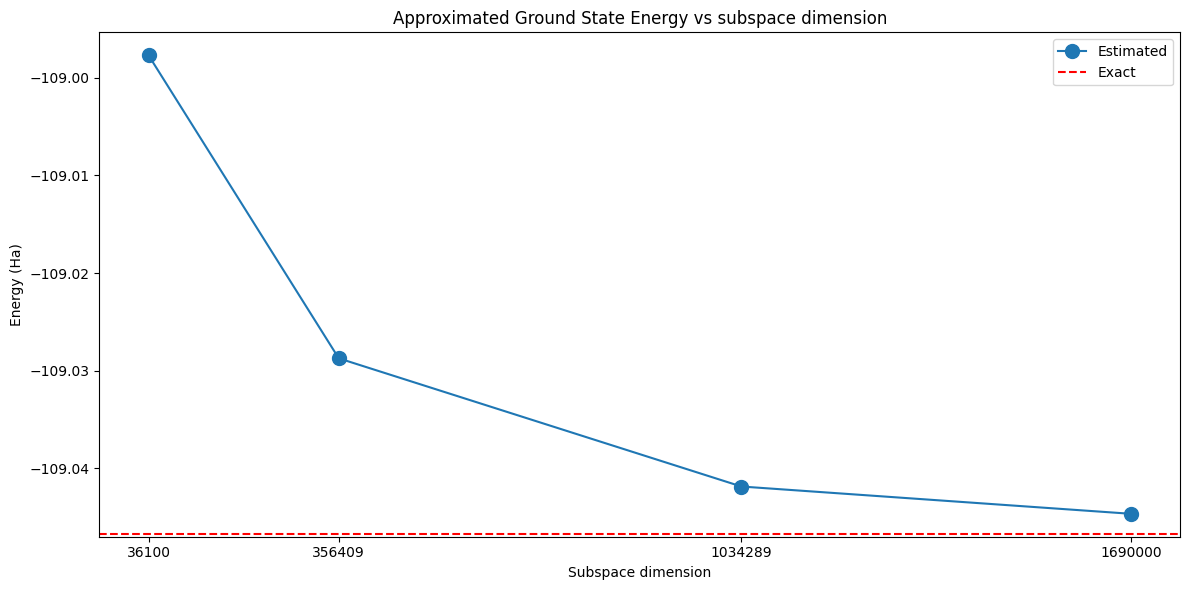

In [4]:
import matplotlib.pyplot as plt

# Data for energies plot
x1 = subspace_dimensions
y1 = np.array(energies) + nuclear_repulsion_energy

fig, axs = plt.subplots(1, 1, figsize=(12, 6))

# Plot energies
axs.plot(x1, y1, marker=".", markersize=20, label="Estimated")
axs.set_xticks(x1)
axs.set_xticklabels(x1)
axs.axhline(y=exact_energy, color="red", linestyle="--", label="Exact")
axs.set_title("Approximated Ground State Energy vs subspace dimension")
axs.set_xlabel("Subspace dimension")
axs.set_ylabel("Energy (Ha)")
axs.legend()


plt.tight_layout()
plt.show()

## Setting an explicit bound with `max_dim`

In the sweep above, the subspace dimension was controlled only indirectly. `samples_per_batch` sets how many bitstrings are drawn into each batch, but the dimension of the resulting subspace is determined by how many *distinct* spin-alpha and spin-beta strings those bitstrings contain, and the pool of configurations available for subsampling grows from one configuration recovery iteration to the next. That is why the subspace dimensions on the horizontal axis above are irregular numbers that we did not pick.

The `max_dim` argument of `diagonalize_fermionic_hamiltonian` bounds the dimension directly. It limits the number of CI strings retained in each spin sector, and since the subspace is spanned by the Cartesian product of the two sectors, its dimension is the product of the two sector dimensions:

- `max_dim=d` limits both sectors to `d` strings, so the subspace dimension is at most `d ** 2`.
- `max_dim=(d_a, d_b)` limits the spin-alpha and spin-beta sectors separately, so the subspace dimension is at most `d_a * d_b`. When `symmetrize_spin=True`, the two limits must be equal.
- `max_dim=None`, the default, imposes no limit.

When a batch contains more strings than the limit allows, the least important ones are discarded: the strings passed via `include_configurations` are kept first, followed by the strings carried over from the previous iteration (see `carryover_threshold`), and the remaining slots are filled with the sampled strings in decreasing order of how often they were sampled.

Because `max_dim` caps the size of the largest diagonalization that the eigenstate solver will be asked to perform, it is a convenient way to keep the solver within a runtime and memory budget: choose `samples_per_batch` generously, and let `max_dim` decide how large the subspace is allowed to grow.

Below, we repeat the study, this time holding `samples_per_batch` fixed and increasing `max_dim`.

In [5]:
list_max_dim = [100, 200, 400, 800]

# Use a generous number of samples per batch, so that max_dim is what limits
# the dimension of the subspace
samples_per_batch = 600

energies_max_dim = []
subspace_dimensions_max_dim = []

for max_dim in list_max_dim:
    result = diagonalize_fermionic_hamiltonian(
        hcore,
        eri,
        bit_array,
        samples_per_batch=samples_per_batch,
        norb=num_orbitals,
        nelec=(num_elec_a, num_elec_b),
        num_batches=num_batches,
        max_iterations=max_iterations,
        symmetrize_spin=True,
        max_dim=max_dim,
        seed=rng,
    )
    energies_max_dim.append(result.energy)
    subspace_dimensions_max_dim.append(int(np.prod(result.sci_state.amplitudes.shape)))

print(f"max_dim:            {list_max_dim}")
print(f"subspace dimension: {subspace_dimensions_max_dim}")

max_dim:            [100, 200, 400, 800]
subspace dimension: [10000, 40000, 160000, 640000]


The subspace dimension is now exactly `max_dim ** 2` in every run: it was chosen rather than discovered. Plotting both sweeps together shows that the accuracy is governed by the subspace dimension itself, whichever argument was used to arrive at it. The two curves need not coincide exactly, though. The `max_dim` runs draw 600 bitstrings per batch and then keep the most frequently sampled strings, so at a given dimension they can retain a better set of configurations than a run that reached that dimension by sampling fewer bitstrings in the first place.

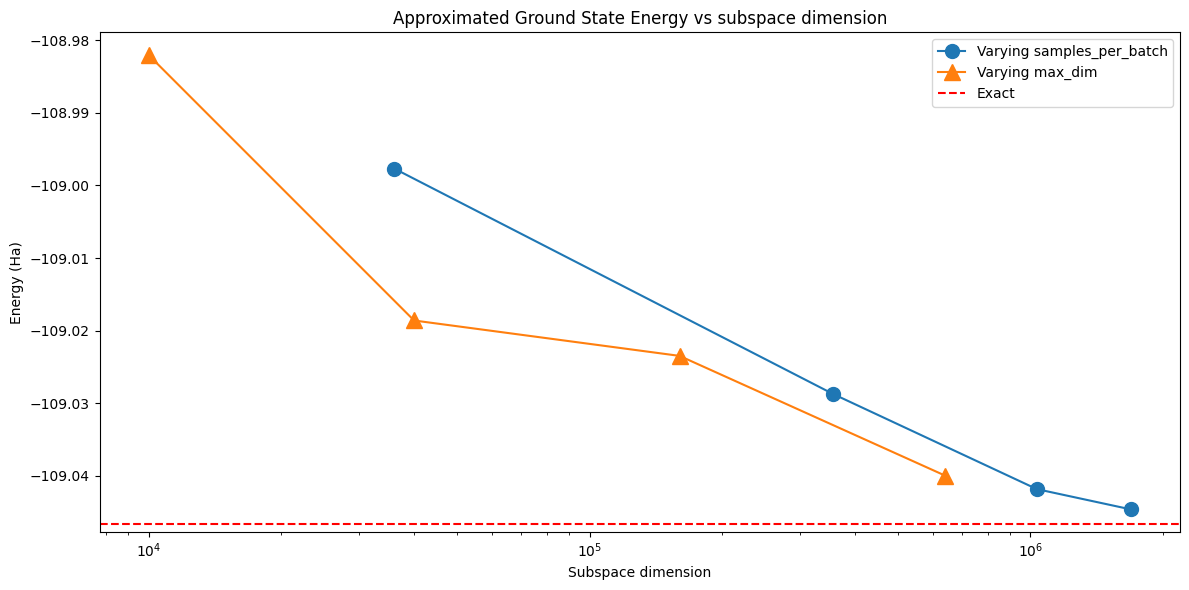

In [6]:
fig, axs = plt.subplots(1, 1, figsize=(12, 6))

axs.plot(
    subspace_dimensions,
    np.array(energies) + nuclear_repulsion_energy,
    marker=".",
    markersize=20,
    label="Varying samples_per_batch",
)
axs.plot(
    subspace_dimensions_max_dim,
    np.array(energies_max_dim) + nuclear_repulsion_energy,
    marker="^",
    markersize=12,
    label="Varying max_dim",
)
axs.axhline(y=exact_energy, color="red", linestyle="--", label="Exact")
axs.set_xscale("log")
axs.ticklabel_format(axis="y", useOffset=False)
axs.set_title("Approximated Ground State Energy vs subspace dimension")
axs.set_xlabel("Subspace dimension")
axs.set_ylabel("Energy (Ha)")
axs.legend()

plt.tight_layout()
plt.show()